# Discrete Event Simulation in Python

In [1]:
# Setup header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import random
import simpy

## Introduction to Dynamic Systems and Discrete-Event Simulation Models

### Decomposing a process into a sequence of events

Imagine you work for a company that produces mobile phones and have been asked to propose ways to optimize the entire supply chain operation. They want to allocate resources better, increase productivity, and identify-eliminate bottlenecks.

A digital twin of the entire operation based on a discrete-event model can help achieve this goal. The first step is to list the process groups involved in the production line and define their processing times (table below). You know that each of the groups of processes you identified involves many sub-processes and tasks, but the focus, for now, is on coding the first version of the model.

Dictionaries are an excellent way to organize information about processes. Time will be measured in days.

In [2]:
# Create a dictionary containing the processes and durations
processes = {
    "Sourcing": 5,
    "Manufacturing": 3,
    "Assembling": 2,
    "Selling": 3,
    "Delivering": 4
}

### Lift: discrete event model

Consider a hotel with five floors (`number_hotel_floors`) and a lift with a capacity for 15 people (`lift_people_capacity`). The lift takes three seconds (3 / 60 minutes) to travel between any two floors (`travel_time_between_floors`) and stops for six seconds (6 / 60 minutes) to let people in or out (`stop_time_open_doors`).

The time units are minutes and the results are stored in `df_results`.

A model named `lift_discrete_event_model()` has been created to simulate this dynamic lift system. Note that while aspects of this system can be well characterized, such as the time of travel between floors, others are unknown, such as when and on which floor people will call the lift. You will learn how to deal with such unknowns in this course.

Let's run the model for five minutes (`sim_time`).

\[The code below isn't working within the notebook. Refer to `lift.py`.\]

In [3]:
def lift_discrete_event_model(sim_time, number_hotel_floors, lift_people_capacity, travel_time_between_floors, stop_time_open_doors):
    NTS = sim_time
    NF = number_hotel_floors
    LC = lift_people_capacity
    TTpF = travel_time_between_floors
    ST = stop_time_open_doors
    
    LP, PinL = 0, 0

    WTpF, PWpF, cNam = np.zeros(NF + 1), np.zeros(NF + 1), ["Time [min]", "Hotel Floor", "Waiting Time [m]",
                                                            "# People Waiting"]
    df = pd.DataFrame({cNam[0]: [0], cNam[1]: [0], cNam[2]: [0], cNam[3]: [0]})  # Initiating the Dataframe
	
    t, nts_i = 0, 0
    
    while nts_i < NTS:  # Time loop (discrete-event simulation model)
      
       	t += 1
        nts_i = t * TTpF
        
        """
		
        FR = [rd.randint(1, NF), max(math.ceil(rd.gauss(0, 2)), 1)]  # Step_1
        PWpF[FR[0]], WTpF[FR[0]] = PWpF[FR[0]] + FR[1], WTpF[FR[0]] + TTpF  # Step_2
        WTpF = np.array([x + TTpF if x > 0 else x for x in WTpF])  # Step_3
        TF = WTpF.argmax() if PinL < LC else 0  # Step_4
        PEL, WTpF[LP] = min(PWpF[LP], LC - PinL) if TF == LP else 0, 0 if TF == LP else WTpF[LP]  # Step_5
        PinL, PWpF[LP] = PinL + PEL if TF == LP else PinL, PWpF[LP] - PEL if TF == LP else PWpF[LP]  # Step_6
        LP, PinL = LP + 1 if TF > LP else LP - 1 if TF < LP else LP, 0 if LP == 0 else PinL  # Step_7
        df = pd.concat([df, pd.DataFrame({cNam[0]: [t * TTpF], cNam[1]: [LP], cNam[2]: [PinL], cNam[3]: [PinL]})])  # Step_8
        df = pd.concat([df, pd.DataFrame([{cNam[0]: t * TTpF, cNam[1]: nf, cNam[2]: WTpF[nf], cNam[3]: PWpF[nf]}
                                          for nf in range(NF + 1)])])  # Step_9
                                          
    	"""
    
    df = pd.read_csv("lift_df.csv")

    fig = px.scatter(df, x=cNam[0], y=cNam[1], color=cNam[2], size=cNam[3], size_max=max(df[cNam[3]]), animation_frame=cNam[0],
               range_color=(min(df[cNam[2]]), max(df[cNam[2]])), range_x=(0, t * TTpF),
               range_y=(0, NF + 1), text = cNam[3])  # Step_10
    
    fig.update_yaxes(range = [0, 7.5])
    
    fig.update_traces(textposition='middle right', textfont=dict(
        family="sans serif",
        size=10,
        color="black"))
    
    fig.add_annotation(text="> Color of circles: waiting time in each floor",
                  xref="paper", yref="paper",
                  x=0, y=1, showarrow=False)
    
    fig.add_annotation(text="> Size and text in circles: number of people waiting in each floor",
                  xref="paper", yref="paper",
                  x=0, y=0.92, showarrow=False)
    
    fig.add_annotation(text="> Moving circle: Lift",
                  xref="paper", yref="paper",
                  x=0, y=0.84, showarrow=False)
    
    fig.show()
    
    df_results = df
    
    return df

# Floor and lift parameters
number_hotel_floors = 5
lift_people_capacity = 15
travel_time_between_floors = 3/60
stop_time_open_doors = 6/60
sim_time = 5

# Run the model
df_results = lift_discrete_event_model(sim_time, number_hotel_floors, lift_people_capacity, travel_time_between_floors, stop_time_open_doors)

### Mathematical models: incorporating key processes

You have created the dictionary processes shown below that contains information about the steps involved in a supply-chain operation of a company that produces mobile phones.

```python
processes = {
    'Sourcing raw material':  5,
    'Transport of raw material': 1,
    'Manufacturing parts': 3,
    'Assembling parts': 2,
    'Selling products': 3,
}
```

Your model is stored in a function named `discrete_model_build_phone()` and simulates your production line by accounting for the processes described in the dictionary. The input arguments of the model are (in order):

1. `processes`: dictionary containing the information about the processes
2. `simulation_time`: duration of the run

The time in the model is in days.

\[I have imported `matplotlib.pyplot` as `plt`.\]

In [4]:
def discrete_model_build_phone(processes_dictionary, simulation_time):
    # Initialize variables
    time = 0
    supply_chain = 0

    time_all = np.array([[0],[0]])

    # Run model
    while (time < simulation_time):
        # Update the supply_chain number
        supply_chain += 1
        process_names = list(processes_dictionary.keys())

        for p in range(len(process_names)):
            process_name_p = process_names[p]

            # Add the process time to the time variable
            time += processes_dictionary[process_name_p]
            time_all = np.append(time_all,np.array([[time], [processes_dictionary[process_name_p]]]), axis=1)
            if (time + processes_dictionary[process_name_p] > simulation_time):
                return time_all

            print(f'Time = {time} days | Process Complete: {process_name_p}')

        print(f'COMPLETED: Supply-Chain cycle #{supply_chain} | Time = {time} days')


processes = {
    "Sourcing raw material":  5,
    "Transport of raw material": 1,
    "Manufacturing parts": 3,
    "Assembling parts": 2,
    "Selling products": 3,
}

* You realized you forgot to include the `"Delivering products"` process in your processes dictionary, so add it, considering this process usually takes about 1.5 days.
* Assign variable `simulation_time` with the simulation period of 1 year, expressed in days.

In [5]:
# Add the new key-value pair to the processes dictionary
processes["Delivering products"] = 1.5

# Assign the simulation time
simulation_time = 365

# Run the model
time_all = discrete_model_build_phone(processes, simulation_time)

Time = 5 days | Process Complete: Sourcing raw material
Time = 6 days | Process Complete: Transport of raw material
Time = 9 days | Process Complete: Manufacturing parts
Time = 11 days | Process Complete: Assembling parts
Time = 14 days | Process Complete: Selling products
Time = 15.5 days | Process Complete: Delivering products
COMPLETED: Supply-Chain cycle #1 | Time = 15.5 days
Time = 20.5 days | Process Complete: Sourcing raw material
Time = 21.5 days | Process Complete: Transport of raw material
Time = 24.5 days | Process Complete: Manufacturing parts
Time = 26.5 days | Process Complete: Assembling parts
Time = 29.5 days | Process Complete: Selling products
Time = 31.0 days | Process Complete: Delivering products
COMPLETED: Supply-Chain cycle #2 | Time = 31.0 days
Time = 36.0 days | Process Complete: Sourcing raw material
Time = 37.0 days | Process Complete: Transport of raw material
Time = 40.0 days | Process Complete: Manufacturing parts
Time = 42.0 days | Process Complete: Assem

Let's plot the model results to help identify model response patterns for more actionable information by plotting `cumulative_time` vs. `individual_process_time`.

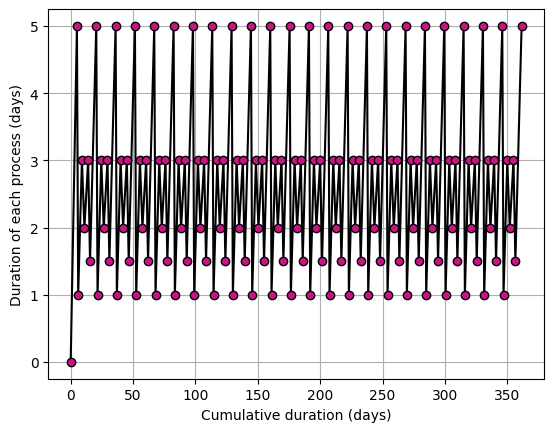

In [6]:
cumulative_time = time_all[0]
individual_process_time = time_all[1]

# Create 2D plot
plt.plot(cumulative_time, individual_process_time,
         color='black', markerfacecolor='mediumvioletred',
         marker='o', markersize=6, linewidth=1.5)

plt.xlabel("Cumulative duration (days)")
plt.ylabel("Duration of each process (days)")
plt.grid()
plt.show()

How many supply chain cycles could be completed in 5 years if the `"Delivering finished products"` to consumers process could be reduced to one day?

Assume there are no leap years. Run the code in the console after making the necessary changes.

In [7]:
processes["Delivering finished products to consumers"] = 1
simulation_time = 365 * 5
time_all = discrete_model_build_phone(processes, simulation_time)

Time = 5 days | Process Complete: Sourcing raw material
Time = 6 days | Process Complete: Transport of raw material
Time = 9 days | Process Complete: Manufacturing parts
Time = 11 days | Process Complete: Assembling parts
Time = 14 days | Process Complete: Selling products
Time = 15.5 days | Process Complete: Delivering products
Time = 16.5 days | Process Complete: Delivering finished products to consumers
COMPLETED: Supply-Chain cycle #1 | Time = 16.5 days
Time = 21.5 days | Process Complete: Sourcing raw material
Time = 22.5 days | Process Complete: Transport of raw material
Time = 25.5 days | Process Complete: Manufacturing parts
Time = 27.5 days | Process Complete: Assembling parts
Time = 30.5 days | Process Complete: Selling products
Time = 32.0 days | Process Complete: Delivering products
Time = 33.0 days | Process Complete: Delivering finished products to consumers
COMPLETED: Supply-Chain cycle #2 | Time = 33.0 days
Time = 38.0 days | Process Complete: Sourcing raw material
Time

(Above code not working properly for some reason.)

### Developing a discrete-event model

You have been asked to develop a discrete-event model for a farming operation to help allocate resources, increase productivity and identify-eliminate bottlenecks.

You are still discussing the different processes involved with your colleagues and in what detail they should be represented in the model. Thus, you have agreed that the information will be compiled in a dictionary named `process_dict` with the following structure. The idea is that this dictionary will be updated as more information about the processes becomes available.

```python
process_dict = {
    "Process name 1": "duration",
    "Process name 2": "duration",
    # ...
}
```

Let's build a generic discrete event model named `discrete_model_farm()` that can schedule any number of discrete events defined in the dictionary.

The input arguments of the model are (in order):

1. `process_dict`: Dictionary with information about the processes
2. `simulation_time`: Simulation period

Time in the model will be measured in days.

* Initialize the state variables of the model, `time` (tracks time) and `supply_chain` (tracks number of cycles) and set them to zero.
* Define the ending condition so that the model runs while `time` is less than `simulation_time`.
* Add the duration of the process to the state variable `time`.


In [8]:
def discrete_model_farm(process_dict, simulation_time):
  # Initialize variables
  time = 0
  supply_chain = 0

  # Run model
  while (time < simulation_time):
      # Update the supply_chain number
      supply_chain += 1
      process_names = list(process_dict.keys())

      for p in range(len(process_names)):
          # Add process time to the time variable
          event_duration = process_dict[process_names[p]]

          # Clock in the process in the simulation time
          if (simulation_time <= time + event_duration):
              break

          time += event_duration
          print(process_names[p] + str(" (completed): time = ") + str(time))

      print(f'=> COMPLETED: Production cycle #{supply_chain} | time = {time} days')
      
      if (simulation_time <= time + event_duration):
          break

### Running the discrete event model

Your farming operation team has finally listed the processes they want to include in this version of the discrete event model, which you plan to continue refining in the future. The processes are provided in the table below, and the time is in days.

| Key | Value |
|-----|-------|
| Compost | 5 |
| Amendment | 3 |
| Weeding | 4 |
| Planting | 2 |
| Watering and growing | 60 |
| Harvesting | 7 |
| Delivery | 2 |

Let's build the dictionary containing this list of processes and run the model for 365 days.

In [9]:
# Create dictionary
process_dict = {
    "Compost": 5,
    "Amendment": 3,
    "Weeding": 4,
    "Planting": 2,
    "Watering and growing": 60,
    "Harvesting": 7,
    "Delivery": 2
}

# Simulatiom time (days)
simulation_time = 365

# Run the model
discrete_model_farm(process_dict, simulation_time)

Compost (completed): time = 5
Amendment (completed): time = 8
Weeding (completed): time = 12
Planting (completed): time = 14
Watering and growing (completed): time = 74
Harvesting (completed): time = 81
Delivery (completed): time = 83
=> COMPLETED: Production cycle #1 | time = 83 days
Compost (completed): time = 88
Amendment (completed): time = 91
Weeding (completed): time = 95
Planting (completed): time = 97
Watering and growing (completed): time = 157
Harvesting (completed): time = 164
Delivery (completed): time = 166
=> COMPLETED: Production cycle #2 | time = 166 days
Compost (completed): time = 171
Amendment (completed): time = 174
Weeding (completed): time = 178
Planting (completed): time = 180
Watering and growing (completed): time = 240
Harvesting (completed): time = 247
Delivery (completed): time = 249
=> COMPLETED: Production cycle #3 | time = 249 days
Compost (completed): time = 254
Amendment (completed): time = 257
Weeding (completed): time = 261
Planting (completed): time =

## Developing Discrete Event Models Using SimPy

### Building a car washer model with SimPy

Consider that a company purchased a commercial car washer and wants to optimize its operation to increase profitability. Building a discrete-event model can be helpful because it can help identify bottlenecks, streamline resources, and incrementally adjust processes towards reaching full capacity.

The commercial car washer takes five minutes to complete a car wash cycle.

Build a discrete-event model that mimics the behavior of this machine, and run it for eight hours (480 minutes) to predict the number of cars washed, and log the time of completion of each cycle.

In [10]:
def car_wash(env):
    car_wash_num = 0
    while True:
      car_wash_num += 1

      # Get the current simulation time and add process time
      print(f'Time {env.now:02d} min | Car Wash # {car_wash_num:02d}')
      yield env.timeout(5)

# Create SimPy Environment and add process generator
env = simpy.Environment()
env.process(car_wash(env))

# Run model
env.run(until=8 * 60)

Time 00 min | Car Wash # 01
Time 05 min | Car Wash # 02
Time 10 min | Car Wash # 03
Time 15 min | Car Wash # 04
Time 20 min | Car Wash # 05
Time 25 min | Car Wash # 06
Time 30 min | Car Wash # 07
Time 35 min | Car Wash # 08
Time 40 min | Car Wash # 09
Time 45 min | Car Wash # 10
Time 50 min | Car Wash # 11
Time 55 min | Car Wash # 12
Time 60 min | Car Wash # 13
Time 65 min | Car Wash # 14
Time 70 min | Car Wash # 15
Time 75 min | Car Wash # 16
Time 80 min | Car Wash # 17
Time 85 min | Car Wash # 18
Time 90 min | Car Wash # 19
Time 95 min | Car Wash # 20
Time 100 min | Car Wash # 21
Time 105 min | Car Wash # 22
Time 110 min | Car Wash # 23
Time 115 min | Car Wash # 24
Time 120 min | Car Wash # 25
Time 125 min | Car Wash # 26
Time 130 min | Car Wash # 27
Time 135 min | Car Wash # 28
Time 140 min | Car Wash # 29
Time 145 min | Car Wash # 30
Time 150 min | Car Wash # 31
Time 155 min | Car Wash # 32
Time 160 min | Car Wash # 33
Time 165 min | Car Wash # 34
Time 170 min | Car Wash # 35
Time 

### Modeling a car production line: Python generators

You have been asked to build a discrete event model to help optimize a car production line. To get started, you had to identify the main groups of processes involved in the production line. These are (1) welding and painting and (2) assembly and testing. Of course, each of these groups of processes involves many sub-processes and tasks, but for now, you are focused on coding a first, high-level version of the model.

Since you have already identified the critical groups of processes, it's time to determine the average time each process takes to complete. You did your research and came up with 15 hours for welding and painting and 24 hours for assembling parts and testing.

\[I have imported `simpy`.\]

Time in the model is in hours.

In [11]:
# Defining a generator that includes the processes
def car_production_line_gen(env):
  car_number = 0
    
  while True:
    car_number += 1

    # Process 1: Clock the time requirement for welding and painting
    yield env.timeout(15)
    print(f'Car {car_number}: Welding and painting (completed) => time = {env.now}')

    # Process 2: Clock in time for process 2 and yield it
    yield env.timeout(24)
    print(f'Car {car_number}: Assembly of parts and testing (completed) => time = {env.now}')

    # Print car ready for shipment
    print(f'Car {car_number}: Car ready for shipping! time = {env.now} hours')

### Modeling a car production line: create and run the model

In this exercise, you'll continue to work on the car production line example from the previous exercise.

Now that you have created the generator `car_production_line_gen()`, which clocks in and yields the duration of processes involved in the production line ("welding and painting" and "assembly and testing"), it's time to run your SimPy model!

In [12]:
# Create your SimPy environment
env = simpy.Environment()

# Add the process to the environment
env.process(car_production_line_gen(env))

# Run your discrete-event model
env.run(until=1000)

Car 1: Welding and painting (completed) => time = 15
Car 1: Assembly of parts and testing (completed) => time = 39
Car 1: Car ready for shipping! time = 39 hours
Car 2: Welding and painting (completed) => time = 54
Car 2: Assembly of parts and testing (completed) => time = 78
Car 2: Car ready for shipping! time = 78 hours
Car 3: Welding and painting (completed) => time = 93
Car 3: Assembly of parts and testing (completed) => time = 117
Car 3: Car ready for shipping! time = 117 hours
Car 4: Welding and painting (completed) => time = 132
Car 4: Assembly of parts and testing (completed) => time = 156
Car 4: Car ready for shipping! time = 156 hours
Car 5: Welding and painting (completed) => time = 171
Car 5: Assembly of parts and testing (completed) => time = 195
Car 5: Car ready for shipping! time = 195 hours
Car 6: Welding and painting (completed) => time = 210
Car 6: Assembly of parts and testing (completed) => time = 234
Car 6: Car ready for shipping! time = 234 hours
Car 7: Welding an

### Managing payment queues

A clothes shop becomes very busy at peak hours when people often queue to pay. Currently, there is only one cashier, and you have been asked to do a cost/benefit analysis to determine how many cashiers would be needed to reduce waiting times as much as possible to increase profitability.

You have decided to build a discrete event model. You know that:

* On average, a new customer joins the queue every 15 seconds during peak hours;
* Customers usually bring several items with them, typically between 1 and 20; and
* It takes an average of 3 seconds to scan an item in the cashier, and the payment generally takes another 20 seconds.

* Complete the statement that requests a counter.
* Clock in the time spent at the cashier (scanning items and paying).
* Create the resource named `counter` with a capacity of 1 (which means 1 counter).


In [13]:
NEW_CUSTOMERS = 30
INTERVAL_CUSTOMERS = 15
TIME_PAY = 20
TIME_SCAN_PER_ITEM = 3


def customer(env, customer_num, counter):
    num_items = random.randint(1, 20)
    print(f'Time: {env.now:7.4f} sec | Customer {customer_num:02d} > Joining the queue with {num_items:02d} items!')

    # Open the resource counter request
    with counter.request() as request:
        yield request
        print(f'Time: {env.now:7.4f} sec | Customer {customer_num:02d} > Got to cashier!')
        time_counter = TIME_PAY + random.randint(1, 20) * TIME_SCAN_PER_ITEM

        # Yield the processing time
        yield env.timeout(time_counter)
        print(f'Time: {env.now:7.4f} sec | Customer {customer_num:02d} > Finished')


def source(env, total_num_customers, interval, counter):
    """Source generates customers randomly"""
    
    for i in range(total_num_customers):
        c = customer(env, i + 1, counter)
        env.process(c)
        # Time between new people arriving and clocking it in
        t = random.expovariate(1.0 / interval)
        yield env.timeout(t)


env = simpy.Environment()

# Create resource
counter = simpy.Resource(env, capacity=1)
env.process(source(env, NEW_CUSTOMERS, INTERVAL_CUSTOMERS, counter))
env.run()

Time:  0.0000 sec | Customer 01 > Joining the queue with 12 items!
Time:  0.0000 sec | Customer 01 > Got to cashier!
Time:  7.9384 sec | Customer 02 > Joining the queue with 17 items!
Time: 18.2898 sec | Customer 03 > Joining the queue with 05 items!
Time: 40.5299 sec | Customer 04 > Joining the queue with 18 items!
Time: 47.0000 sec | Customer 01 > Finished
Time: 47.0000 sec | Customer 02 > Got to cashier!
Time: 58.9953 sec | Customer 05 > Joining the queue with 18 items!
Time: 82.0000 sec | Customer 02 > Finished
Time: 82.0000 sec | Customer 03 > Got to cashier!
Time: 86.1939 sec | Customer 06 > Joining the queue with 18 items!
Time: 90.2918 sec | Customer 07 > Joining the queue with 19 items!
Time: 135.0000 sec | Customer 03 > Finished
Time: 135.0000 sec | Customer 04 > Got to cashier!
Time: 155.6156 sec | Customer 08 > Joining the queue with 13 items!
Time: 193.4078 sec | Customer 09 > Joining the queue with 16 items!
Time: 194.0000 sec | Customer 04 > Finished
Time: 194.0000 sec |

**What is the minimum number of counters required so that they stop being the limiting factor in the speed of the queue?**

To help answer this question, the SimPy code you developed in the previous step is provided. Some object names have been changed.

Note that the model contains randomizing functions, covered in future videos, and we need to use `random.seed(RANDOM_SEED)` to enable a deterministic answer to this exercise—we've set `RANDOM_SEED = 42`.

```python
random.seed(42)
env_my_model = simpy.Environment()
counter_my_model = simpy.Resource(env_my_model, capacity=1)
env_my_model.process(source_my_model(env_my_model, NEW_CUSTOMERS, INTERVAL_CUSTOMERS, counter_my_model))
env_my_model.run()
```

Paste the code provided in the console, incrementally increasing the `capacity` argument (line 3), and examine the time required to serve 30 customers, which is printed in the console.

In [14]:
def customer_my_model(env, customer_number, counter):
    num_items = random.randint(1, 20)
    print(f'Time: {env.now:7.4f} sec | Customer {customer_number:02d} > Joining the queue with {num_items:02d} items!')

    # Open the resource counter request
    with counter.request() as request:
        # Yield the request
        yield request

        # If time at cashier, then scan the items and complete payment
        print(f'Time: {env.now:7.4f} sec | Customer {customer_number:02d} > Got to cashier!')
        time_counter = TIME_PAY + random.randint(1, 20) * TIME_SCAN_PER_ITEM

        # Yield the processing time
        yield env.timeout(time_counter)
        print(f'Time: {env.now:7.4f} sec | Customer {customer_number:02d} > Finished')


def source_my_model(env, total_mum_customers, interval, counter):
    """Source generates customers randomly"""
    
    for i in range(total_mum_customers):
        c = customer_my_model(env, i + 1, counter)
        env.process(c)
        # time between new people arriving and clocking it in
        t = random.expovariate(1.0 / interval)
        yield env.timeout(t)

In [20]:
random.seed(42)
env_my_model = simpy.Environment()
counter_my_model = simpy.Resource(env_my_model, capacity=4)
env_my_model.process(source_my_model(env_my_model, NEW_CUSTOMERS, INTERVAL_CUSTOMERS, counter_my_model))
env_my_model.run()

Time:  0.0000 sec | Customer 01 > Joining the queue with 01 items!
Time:  0.0000 sec | Customer 01 > Got to cashier!
Time: 15.3009 sec | Customer 02 > Joining the queue with 05 items!
Time: 15.3009 sec | Customer 02 > Got to cashier!
Time: 19.5143 sec | Customer 03 > Joining the queue with 18 items!
Time: 19.5143 sec | Customer 03 > Got to cashier!
Time: 36.4519 sec | Customer 04 > Joining the queue with 02 items!
Time: 36.4519 sec | Customer 04 > Got to cashier!
Time: 47.0000 sec | Customer 01 > Finished
Time: 47.3009 sec | Customer 02 > Finished
Time: 48.5143 sec | Customer 03 > Finished
Time: 49.8439 sec | Customer 05 > Joining the queue with 08 items!
Time: 49.8439 sec | Customer 05 > Got to cashier!
Time: 51.3196 sec | Customer 06 > Joining the queue with 18 items!
Time: 51.3196 sec | Customer 06 > Got to cashier!
Time: 59.4519 sec | Customer 04 > Finished
Time: 65.1399 sec | Customer 07 > Joining the queue with 18 items!
Time: 65.1399 sec | Customer 07 > Got to cashier!
Time: 84.

(Answer appears to be 3 cashiers.)

### Modeling a petrol station: Python generators

Consider that a client wants to build a gas station, and you have been asked to create a discrete event model to help determine the optimal number of gas pumps and the size of the common fuel tank used by the pumps. This model requires simulating the cars arriving at the gas station and the stations' resources: the pumps and the fuel tank. In this exercise, we will focus on the following two steps:

1. Create a generator to simulate the arrival of the cars at the gas station, requesting a pump, and refilling the car tanks.
2. Create a generator to check the level of the tank and request a refill tank when needed. Also, the behavior of the refill tank needs to be modeled.

In the next exercise, you will create the SimPy environment, add processes and resources, and run simulations.

The number of gas pumps are limited and simulated using a SimPy resource stored in the variable `gas_station_pumps`.